# GPROF-IR

This notebooks evaluates the operational version of the GPROF-IR retrieval on the SatRain benchmark dataset. This notebook requires the ``gprof_ir`` package to be installed.

In [17]:
!pip install git+https://github.com/simonpf/gprof_ir

  Cloning https://github.com/simonpf/gprof_ir to /tmp/pip-req-build-l3nn_ae9
  Running command git clone --filter=blob:none --quiet https://github.com/simonpf/gprof_ir /tmp/pip-req-build-l3nn_ae9
  Resolved https://github.com/simonpf/gprof_ir to commit 50873929a878aa452623cefdd72e3383f41bd507
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## The Retrieval Callback

The ``gprof_ir`` package provides a direct interface to run the GPROF-IR retrieval on the SatRain data. For the baseline results, we run the configuration GPROF-IR (GMI, 3) configuration that is used for operational processing.

In [18]:
from gprof_ir.satrain import GPROFIRRetrieval

ir_input_data = ["/data2/satellite_data/gpm/merged_ir/"]

gprof_ir_retrieval = GPROFIRRetrieval(
    ir_input_data,
    variant="gmi",
    n_steps=3,
    device="cuda:0",
    dtype="bfloat16"
)

## Case Study

In [11]:
from satrain.target import TargetConfig
from satrain.evaluation import Evaluator

target_config = TargetConfig(min_rqi=0.5)
evaluator = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[],
    download=True,
    target_config=target_config,
)

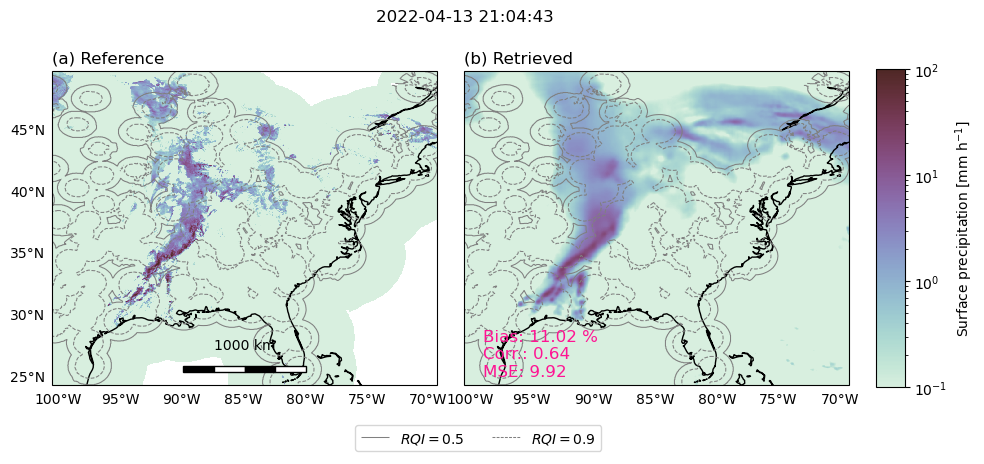

In [12]:
fig = evaluator.plot_retrieval_results(811, gprof_ir_retrieval, include_metrics=True)

## Evaluation

In [19]:
import logging
LOGGER = logging.getLogger("evaluation")
    
results = []
domains = ["austria", "conus", "korea"]
base_sensors = ["atms", "gmi"]

for sensor in base_sensors:
    for domain in domains:
        LOGGER.info("Running evaluation for domain '%s'.", domain)
        evaluator = Evaluator(
            domain=domain,
            base_sensor=sensor,
            geometry="gridded",
            retrieval_input=[],
            download=True,
            target_config=target_config,
        )
        evaluator.evaluate(
            gprof_ir_retrieval,
            n_processes=1
        )
        res = evaluator.get_results()
        results.append(res)
        res.to_netcdf(f"gprof_ir_{sensor}_{domain}.nc")

INFO     Running evaluation for domain 'austria'.

Output()

INFO     Running evaluation for domain 'conus'.

Output()

INFO     Running evaluation for domain 'korea'.

...

Output()

INFO     Running evaluation for domain 'conus'.

Output()

INFO     Running evaluation for domain 'korea'.

Output()